# Error Models' Feature Importance Analysis

---

Inspect which input features drive the default UNIQUE Random Forest error model (target: `l1_error`; features: `Manhattan Distance`, `Ensemble Variance`, `Predictions`) using:
- **Gini feature importance** from the trained RF, aggregated across endpoints as a stacked bar chart.
- **SHAP partial dependence plots** on the Test set to visualise how each feature influences the predicted error.

Prerequisite: run `../../scripts/run_unique.py` so the RF error model pickle (`UniqueRandomForestRegressor_model.pkl`) and its input data (`data.csv`) exist under `../../unique_output/{model_id}/error_models/UQmetrics_predictions/`.

In [1]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

import shap

/chemotargets/shared/conda/envs/unique-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the endpoints dictionary: {endpoint_group: {model_name: model_id}}
endpoints_dict = {'clint': {'rLM LogCLint': 'clint_rat', 'hLM LogCLint': 'clint_human'},
                  'ppb':   {'LogFu-Rat': 'ppb_rat', 'LogFu-Human': 'ppb_human'},
                  'mdr1':  {'MDCK-MDR1_LogER': 'mdck_mdr1_er'}}

feature_names = ['Manhattan Distance', 'Ensemble Variance', 'Predictions']

# Endpoint display names for plots
endpoints = ['rLM LogCLint', 'hLM LogCLint', 'LogFu-Rat', 'LogFu-Human', 'MDCK-MDR1_LogER']
endpoint_rename = {'rLM LogCLint': 'rLM LogCLint',
                   'hLM LogCLint': 'hLM LogCLint',
                   'LogFu-Rat': 'Rat Logfu',
                   'LogFu-Human': 'Human Logfu',
                   'MDCK-MDR1_LogER': 'MDR1 LogER'}

## Random Forest Gini Importance

Extract the `feature_importances_` attribute from each trained RF error model and plot a stacked bar chart across all endpoints.

In [3]:
feature_importances_data = []

for endpoint, models_dict in endpoints_dict.items():
    for model_name, model_id in models_dict.items():
        # Load RF Error Model
        model = pickle.load(open(f'unique_output/{model_id}/error_models/UQmetrics_predictions/UniqueRandomForestRegressor_model.pkl', 'rb'))
        importances = model.feature_importances_

        for i, feature in enumerate(feature_names):
            feature_importances_data.append([model_name, feature, importances[i]])

feature_importances_df = pd.DataFrame(feature_importances_data, columns=['Endpoint', 'Feature', 'Importance'])
feature_importances_df

,Endpoint,Feature,Importance
0,rLM LogCLint,Manhattan Distance,0.320044
1,rLM LogCLint,Ensemble Variance,0.262326
2,rLM LogCLint,Predictions,0.417630
3,hLM LogCLint,Manhattan Distance,0.255866
4,hLM LogCLint,Ensemble Variance,0.202940
5,hLM LogCLint,Predictions,0.541194
6,LogFu-Rat,Manhattan Distance,0.305049
7,LogFu-Rat,Ensemble Variance,0.368732
8,LogFu-Rat,Predictions,0.326219
9,LogFu-Human,Manhattan Distance,0.306261


/tmp/ipykernel_426726/970174159.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x=i, y=bottom_stack[i] + height / 2, s=f"{height:.2f}", ha='center', va='center', fontsize=9)


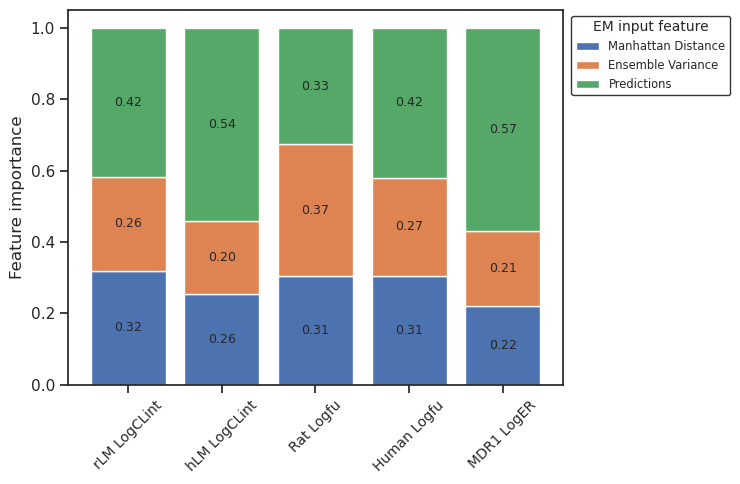

In [4]:
# Pivot the data for the stacked bar chart
stacked_data = feature_importances_df.pivot(index="Endpoint", columns="Feature", values="Importance")
stacked_data = stacked_data.reindex(endpoints).rename(index=endpoint_rename)

plt.figure(figsize=(8, 5))

bottom_stack = np.zeros(len(stacked_data))
for feature in feature_names:
    plt.bar(x=np.arange(len(stacked_data)), height=stacked_data[feature], label=feature, bottom=bottom_stack)
    for i, height in enumerate(stacked_data[feature]):
        plt.text(x=i, y=bottom_stack[i] + height / 2, s=f"{height:.2f}", ha='center', va='center', fontsize=9)
    bottom_stack += stacked_data[feature]

plt.xlabel("")
plt.xticks(np.arange(len(stacked_data)), stacked_data.index, rotation=45, fontsize=10)
plt.ylabel("Feature importance", fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1),
           fontsize='x-small', title='EM input feature', title_fontsize='small',
           frameon=True, fancybox=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.show()

## SHAP Partial Dependence

For every endpoint, compute the SHAP partial dependence of each input feature on the RF error model's prediction, evaluated on the Test subset.


### rLM LogCLint ###



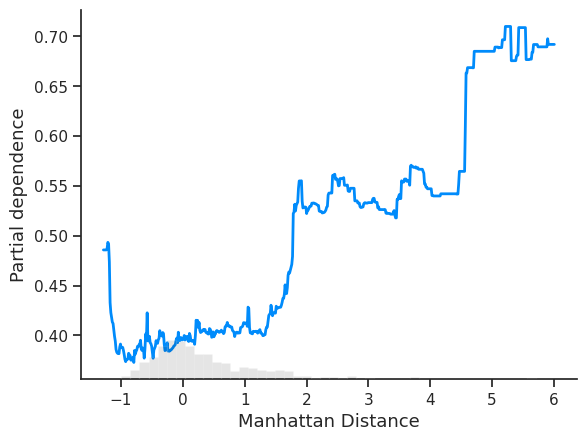

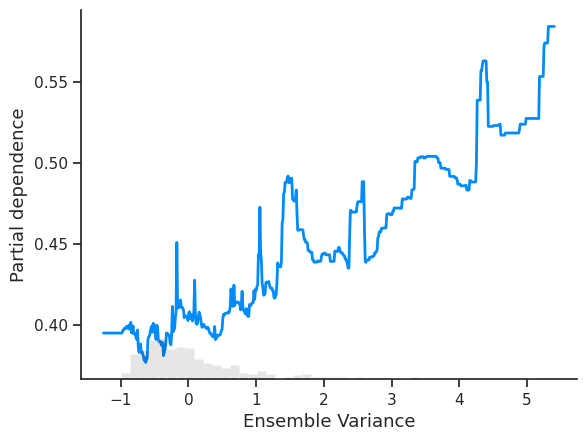

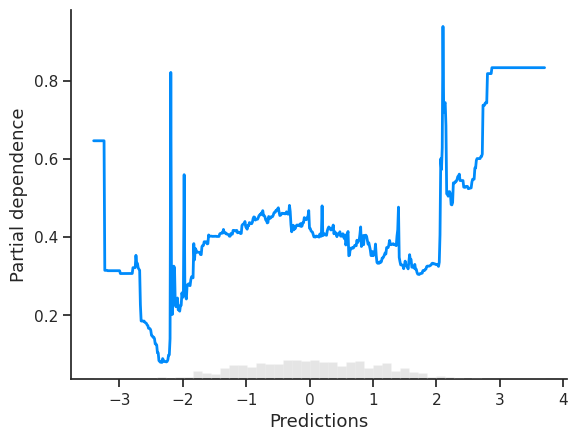


### hLM LogCLint ###



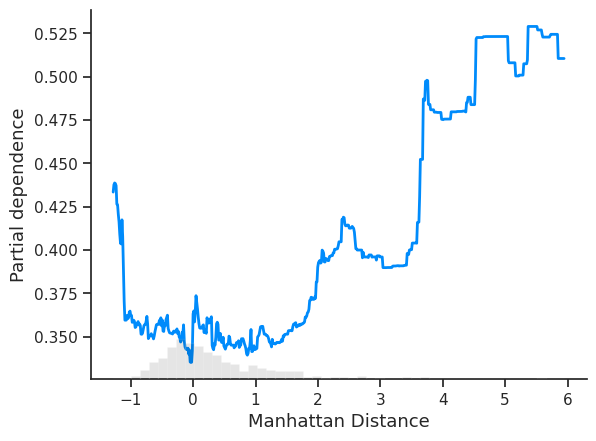

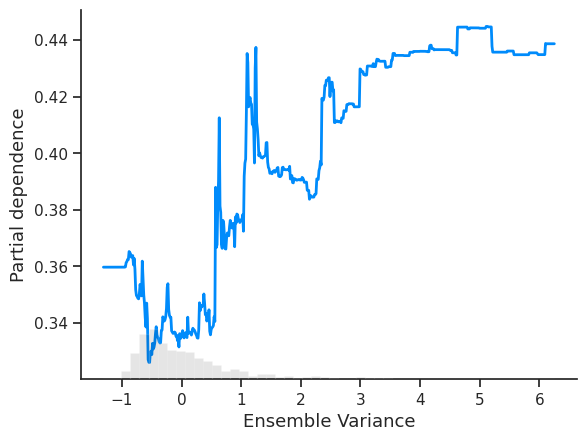

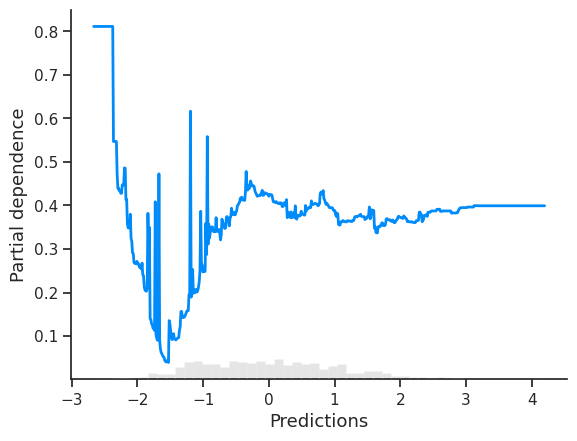


### LogFu-Rat ###



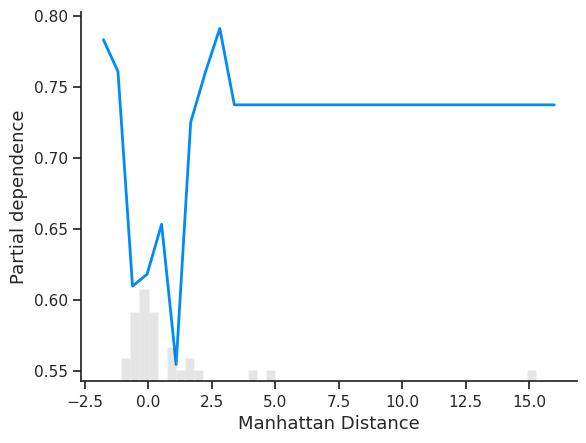

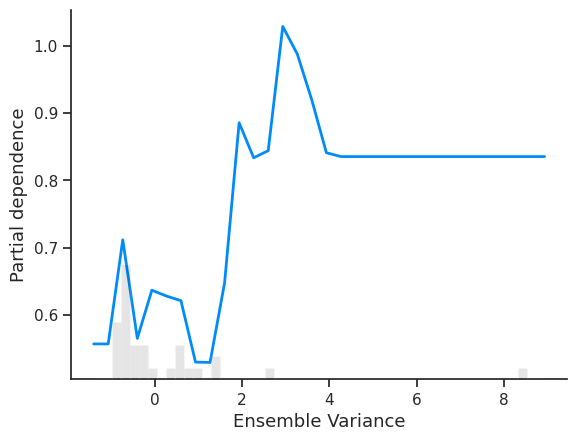

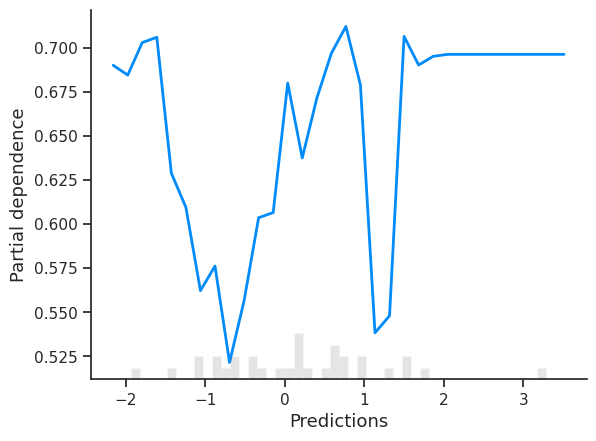


### LogFu-Human ###



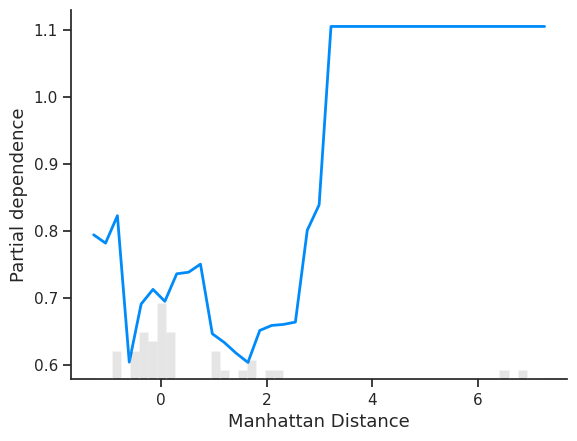

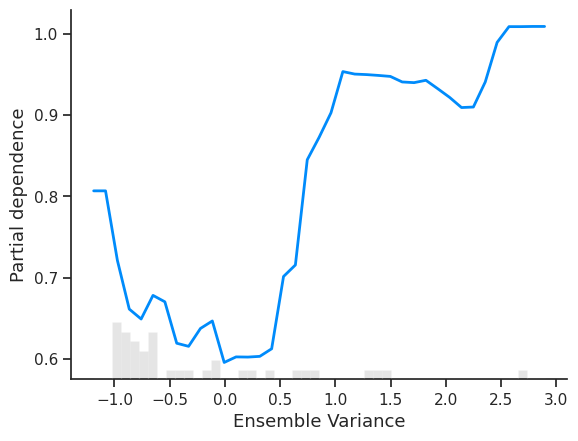

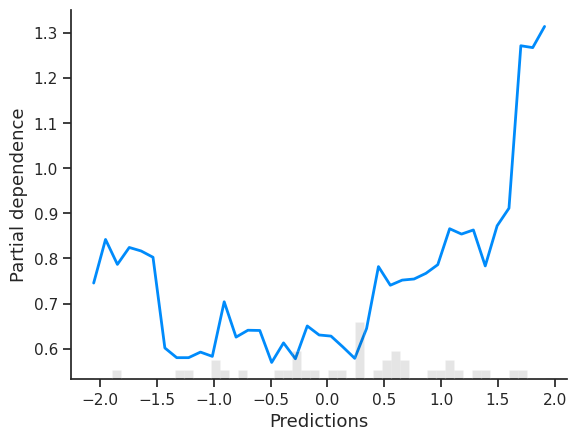


### MDCK-MDR1_LogER ###



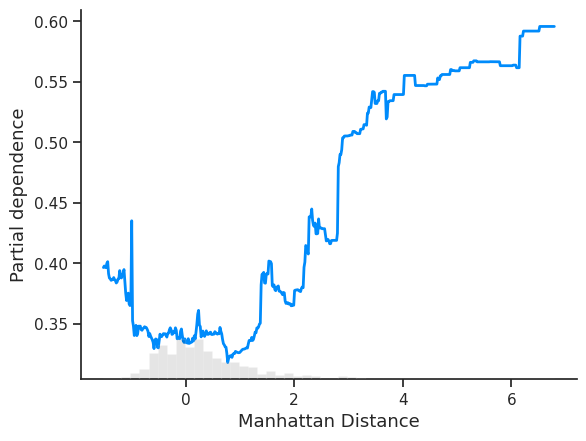

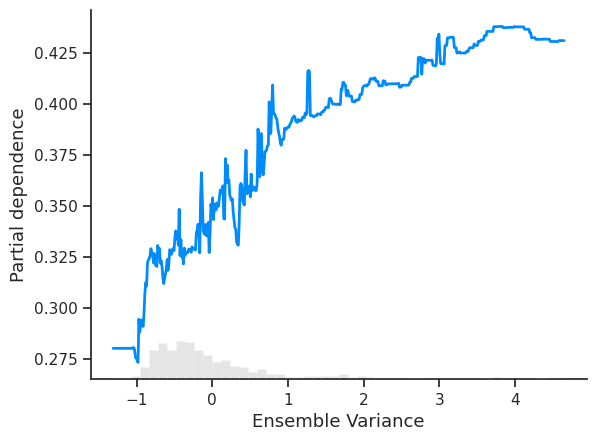

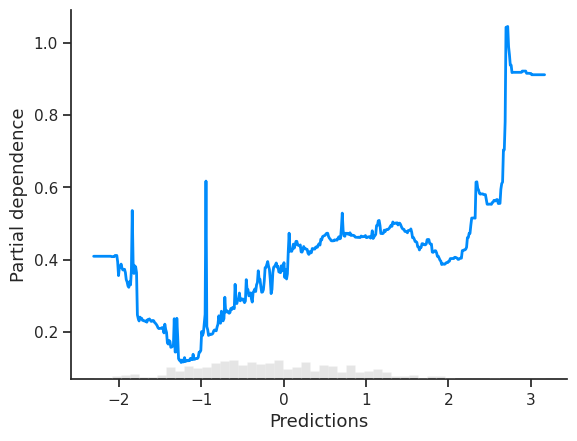

In [5]:
for endpoint, models_dict in endpoints_dict.items():
    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')

        # Load EM input data and select the Test subset
        em_data = pd.read_csv(f'unique_output/{model_id}/error_models/UQmetrics_predictions/data.csv')
        test_data = em_data[em_data['which_set'] == 'TEST']
        X_test = test_data.iloc[:, 3:-1]

        # Load RF Error Model
        model = pickle.load(open(f'unique_output/{model_id}/error_models/UQmetrics_predictions/UniqueRandomForestRegressor_model.pkl', 'rb'))
        model.feature_names_in_ = feature_names
        X_test.columns = feature_names

        # SHAP partial dependence plot for every input feature
        for feature in feature_names:
            shap.partial_dependence_plot(feature, model.predict, X_test,
                                         ice=False, model_expected_value=False, feature_expected_value=False,
                                         ylabel='Partial dependence', npoints=len(X_test))